<a href="https://colab.research.google.com/github/Jabbiks/ML/blob/main/%D0%9B%D0%A0_2_2_%D0%9C%D0%9D_%D0%90%D0%B2%D1%80%D0%B0%D0%BC%D0%B5%D0%BD%D0%BA%D0%BE_3_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")

print("Path to dataset files:", path)

100%|██████████| 22.0k/22.0k [00:00<00:00, 12.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mahmoudshogaa/titanic-dataset/versions/1


In [3]:
df =  pd.read_csv(os.path.join(path, "titanic.csv"))

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


**PassengerId:** Унікальний ідентифікатор для кожного пасажира.

**Survived:** У цьому стовпці вказується, чи вижив пасажир (1), чи ні (0).

**Pclass (Клас квитка):** Показник соціально-економічного статусу, де 1 – найвищий
клас, а 3 – найнижчий.

**Name:** Ім'я пасажира.

**Sex:** Стать пасажира.

**Age:** Вік пасажира. (Примітка: У цьому стовпці можуть бути відсутні значення.)

**SibSp:** Кількість братів і сестер або подружжя пасажира на борту «Титаніка».

**Parch:** Кількість батьків або дітей пасажира на борту «Титаніка».

**Ticket:** Номер квитка.

**Fare:** Сума грошей, яку пасажир сплатив за квиток.

**Основна мета** використання цього набору даних — передбачити, чи вижив пасажир, на основі різних характеристик. Він є популярним вступним набором даних для тих, хто вивчає аналіз даних, машинне навчання та прогностичне моделювання. Варто пам’ятати, що цей набір даних може змінюватися й оновлюватися, тому для отримання найактуальнішої інформації завжди варто перевіряти вебсайт Kaggle або документацію до набору даних.

2. Визначити розмір датасета.
3. Визначити тип даних.

In [4]:
print("Розмір датасета (рядки, стовпці):", df.shape)

Розмір датасета (рядки, стовпці): (891, 12)


In [5]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


4. Визначити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median(skipna=True))

df.drop(['Cabin'], axis=1, inplace=True)
df.drop(['Embarked'], axis=1, inplace=True)

5. Ще раз перевірити наявність пропущених значень.

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


6. Сформувати датасет з обраними стовпцями: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

In [9]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


7. Замінити бінарні ознаки (Стать) на 0 і 1 (але перевірте унікальні значення даного стовпчика). Буває, що є середня стать)

In [10]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [11]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(f'Data types of the dataset:\n{df.dtypes}')

Data types of the dataset:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
Fare        float64
dtype: object


/tmp/ipykernel_994/275882515.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})


8. Вивести описову статистику датасету describe()

In [12]:
df.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,32.204208
std,0.486592,0.836071,0.477990,13.019697,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


9. Ще раз перевірити кількість пропущених даних (впевнитись, що їх немає).

In [13]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


10. Вивести 5 перших рядків датасету.

In [14]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500



11. Вивести 5 останніх рядків датасету.

In [15]:
df.tail()

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.0,13.00
887,1,1,1,19.0,30.00
888,0,3,1,28.0,23.45
889,1,1,0,26.0,30.00
890,0,3,0,32.0,7.75


12. Аналіз виживання залежно від статі: Обчисліть відсоток виживання для кожної статі. Чи була різниця у виживанні між чоловіками та жінками?

In [16]:
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100

print(f'share of survived males: {survival_by_sex[0]:.2f}%')
print(f'Share of survived females: {survival_by_sex[1]:.2f}%')

share of survived males: 18.89%
Share of survived females: 74.20%


In [17]:
print(f'Correlation between sex and survival: {df["Sex"].corr(df["Survived"])}')

Correlation between sex and survival: 0.5433513806577555


 13. Обчисліть відсоток виживання для кожного класу (Pclass). Який клас мав найвищий рівень виживання (дати відповідь)?

In [18]:
class1_surv_rate = df[(df['Pclass'] == 1) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 1].shape[0]
class2_surv_rate = df[(df['Pclass'] == 2) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 2].shape[0]
class3_surv_rate = df[(df['Pclass'] == 3) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 3].shape[0]

print(f'Share of survived class 1 passengers {class1_surv_rate * 100:.2f}%')
print(f'Share of survived class 2 passengers {class2_surv_rate * 100:.2f}%')
print(f'Share of survived class 3 passengers {class3_surv_rate * 100:.2f}%')

Share of survived class 1 passengers 62.96%
Share of survived class 2 passengers 47.28%
Share of survived class 3 passengers 24.24%


14.  Визначте середній вік тих, хто вижив, і тих, хто не вижив. Чи впливає вік на виживання (дати відповідь)?

In [19]:
survived_mean_age = df[df['Survived'] == 1]['Age'].mean()
not_survived_mean_age = df[df['Survived'] == 0]['Age'].mean()

print(f'Mean age of survived passengers: {survived_mean_age:.2f}')
print(f'Mean age of not survived passengers: {not_survived_mean_age:.2f}')

Mean age of survived passengers: 28.29
Mean age of not survived passengers: 30.03


 15. Розподіліть пасажирів на групи за рівнями тарифів (Fare) і обчисліть рівень виживання для кожної групи. Як тариф впливав на шанси виживання (дати відповідь)?

In [20]:
df['Fare_Category'] = pd.qcut(df['Fare'], q=6, labels=False)
for i in range(6):
  surv_rate = df[(df['Fare_Category'] == i) & (df['Survived'] == 1)].shape[0] / df[df['Fare_Category'] == i].shape[0]
  print(f'Shape of survived passengers in bucket {i}: {surv_rate * 100:.2f}%')

Shape of survived passengers in bucket 0: 20.51%
Shape of survived passengers in bucket 1: 19.08%
Shape of survived passengers in bucket 2: 36.69%
Shape of survived passengers in bucket 3: 43.62%
Shape of survived passengers in bucket 4: 41.78%
Shape of survived passengers in bucket 5: 69.80%


/tmp/ipykernel_994/1515389469.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fare_Category'] = pd.qcut(df['Fare'], q=6, labels=False)


Судячи з отриманих даних ми побачили, що пасажири з дорожчими квитками мали вищій шанс вижити

 16. Аналіз класу та тарифу: Визначте середній тариф (Fare) для кожного класу (Pclass). Чи існує значна різниця у тарифах між класами (дати відповідь)?

In [21]:
for i in range (1, 4):
   median_fare = df[df['Pclass'] == i]['Fare'].median()
   print(f'Median fare for class {i}: {median_fare:.2f}')

Median fare for class 1: 60.29
Median fare for class 2: 14.25
Median fare for class 3: 8.05


Ціни на квитки першого класу значно дорожчі за другий та третій класи. Коли різниця між третім та другим у 2 рази, то між другим та першим майже 4 рази.

 17. Як пов'язано середній вік пасажирів з виживанням? Відповідь дати аналітично чи графічно

Аналітичні показники за статусом виживання:
          Середній_вік  Медіанний_вік  Кількість
Survived                                        
0            30.028233           28.0        549
1            28.291433           28.0        342


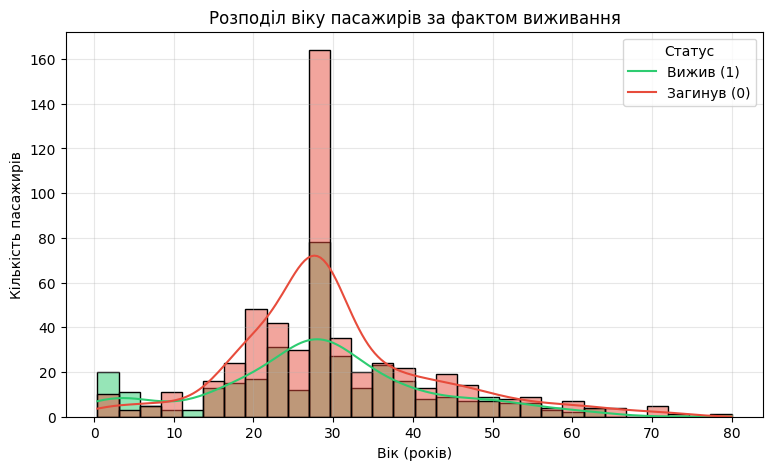

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Аналітичний розрахунок середнього та медіанного віку
age_stats = df.groupby('Survived')['Age'].agg(
    Середній_вік='mean',
    Медіанний_вік='median',
    Кількість='count',
)
print("Аналітичні показники за статусом виживання:")
print(age_stats)

# 2. Графічне відображення (розподіл віку)
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x='Age',
    hue='Survived',
    kde=True,
    bins=30,
    palette=['#e74c3c', '#2ecc71'],
)

plt.title('Розподіл віку пасажирів за фактом виживання')
plt.xlabel('Вік (років)')
plt.ylabel('Кількість пасажирів')
plt.legend(title='Статус', labels=['Вижив (1)', 'Загинув (0)'])
plt.grid(alpha=0.3)
plt.show()

На основі розрахованих статистичних показників та побудованого розподілу можна виділити наступні закономірності щодо впливу віку на рівень виживання:

**Загальна різниця середнього віку:**
Середній вік пасажирів, які вижили, є дещо нижчим (близько 28 років), ніж середній вік загиблих (понад 30 років). Це свідчить про незначне загальне зміщення на користь молодшої групи, хоча сам по собі середній показник згладжує ключові деталі.

**Пріоритетність порятунку дітей:**
Найбільш виражена аномалія спостерігається у віковій групі до 10–12 років. Тут частка тих, хто врятувався, суттєво перевищує кількість загиблих. Це безпосередньо підтверджує дотримання морського правила евакуації «жінки та діти в першу чергу».

**Найбільша група ризику (молодь та середній вік):**
Основний масив пасажирів на судні зосереджений у діапазоні 18–35 років. Саме в цьому сегменті зафіксовано абсолютну більшість втрат. Це пояснюється тим, що значну частку складали молоді чоловіки, чорнороби й пасажири 3-го класу, шанси на евакуацію яких були мінімальними.

**Старша вікова група:**
Для пасажирів віком 50+ років рівень виживання суттєво знижується через обмежену фізичну мобільність під час швидкого затоплення, за винятком поодиноких представників першого класу кают.

**Підсумок:**
Віковий фактор мав нелінійний характер: найвищу ймовірність вижити мали діти, тоді як для дорослих пасажирів вік уже не був самостійною перевагою й відігравав меншу роль, ніж стать та клас каюти.

In [27]:
# Clalculate survival rate per class per sex

for i in range(1, 4):
  for j in range(2):
    surv_rate = df[(df['Pclass'] == i) & (df['Sex'] == j) & (df['Survived'] == 1)].shape[0] / df[(df['Pclass'] == i) & (df['Sex'] == j)].shape[0]
    print(f'Share of survived ("male" if j == 0 else "female") passengers in class {i}: {surv_rate * 100:.2f}%')

Share of survived ("male" if j == 0 else "female") passengers in class 1: 36.89%
Share of survived ("male" if j == 0 else "female") passengers in class 1: 96.81%
Share of survived ("male" if j == 0 else "female") passengers in class 2: 15.74%
Share of survived ("male" if j == 0 else "female") passengers in class 2: 92.11%
Share of survived ("male" if j == 0 else "female") passengers in class 3: 13.54%
Share of survived ("male" if j == 0 else "female") passengers in class 3: 50.00%


18. Побудувати теплову карту коретляції

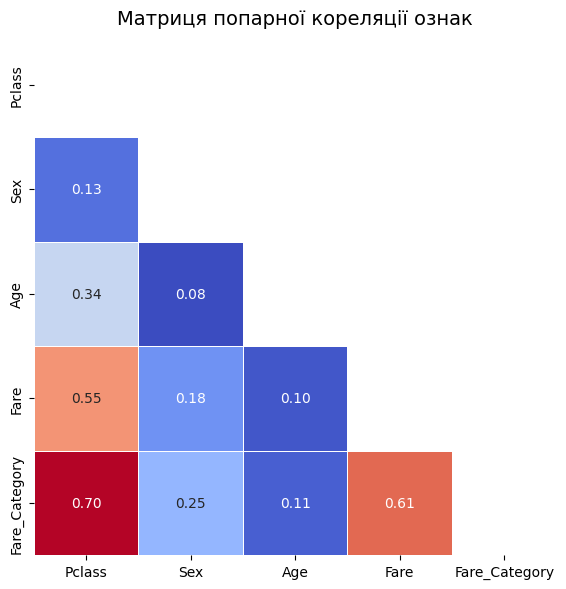

In [28]:
mtx = df.drop('Survived', axis=1).corr(numeric_only=True).abs()

# Побудова теплової карти кореляції
fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    mtx,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=np.triu(np.ones_like(mtx, dtype=bool)), # маскуємо верхній трикутник
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()